##### VGG Pre-trained using PyTorch

###### Imports

In [33]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import json

###### Model Loading

In [34]:
# Load a pretrained VGG-16 model
model = models.vgg16(pretrained=True)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

###### Image Transformations & Class Labels

In [35]:
# Load class labels
with open('imagenet_classes.txt') as f:
    class_names = [line.strip() for line in f.readlines()]

# Define preprocessing transformations
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

###### Image Preprocessing

In [36]:
# Load an image and preprocess it
def preprocess_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image)
    image = image.unsqueeze(0)
    return image

###### Model Inferencing

In [37]:
# Perform inference
def infer(image_path):
    image = preprocess_image(image_path)
    with torch.no_grad():
        output = model(image)
    probabilities = torch.nn.functional.softmax(output[0],dim=0)
    top5_prob,top5_catid = probabilities.topk(5)
    results = [(class_names[catid],prob.item()) for catid,prob in zip(top5_catid,top5_prob)]
    return results

In [38]:
from PIL import Image
from matplotlib import pyplot as plt

def show_image(image_path):
    image=Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

###### Final Results

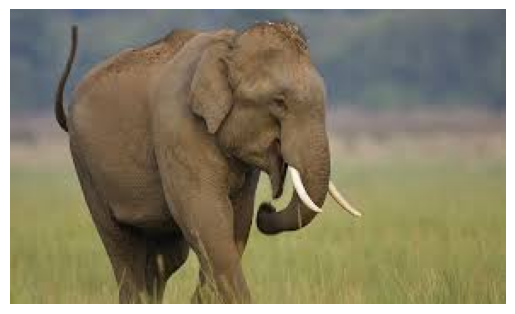

101, tusker 0.6783
385, Indian_elephant 0.2313
386, African_elephant 0.0901
354, Arabian_camel 0.0002
291, lion 0.0000


In [39]:
image_path = 'elephant.jpg'
show_image(image_path)
results = infer(image_path)
for label,prob in results:
    print(f'{label} {prob:.4f}')

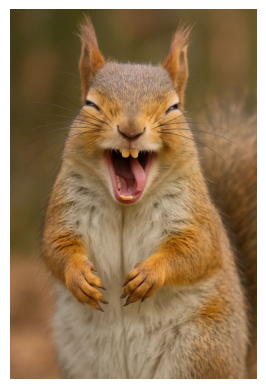

282, tiger_cat 0.3832
335, fox_squirrel 0.3699
285, Egyptian_cat 0.0901
281, tabby 0.0298
277, red_fox 0.0297


In [40]:
image_path = 'squirrel.jpg'
show_image(image_path)
results = infer(image_path)
for label,prob in results:
    print(f'{label} {prob:.4f}')